


**3-Sigma Technique (Standard Deviation)**

*Finding Outliers*



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statistics
import seaborn as sns

In [ ]:
data = pd.read_csv('raw_sales.csv')
data.head()

,datesold,postcode,price,propertyType,bedrooms
0,2007-02-07 00:00:00,2607,525000,house,4
1,2007-02-27 00:00:00,2906,290000,house,3
2,2007-03-07 00:00:00,2905,328000,house,3
3,2007-03-09 00:00:00,2905,380000,house,4
4,2007-03-21 00:00:00,2906,310000,house,3


In [ ]:
def find_anamolies(data):
  anamolies =[]

  random_std = statistics.stdev(data)
  random_mean = statistics.mean(data)

  anamolies_cut_off = random_std * 3

  lower_limit = anamolies_cut_off - random_mean
  upper_limit = anamolies_cut_off + random_mean

  for outliers in data:
    if outliers > upper_limit or outliers < lower_limit:
      anamolies.append(outliers)
  return anamolies

In [ ]:
list1 =  find_anamolies(data['price'])

In [ ]:
len(list1), len(data)

(665, 29580)

In [ ]:
data.price.skew()

np.float64(4.312009366902366)

<Axes: xlabel='price', ylabel='Density'>

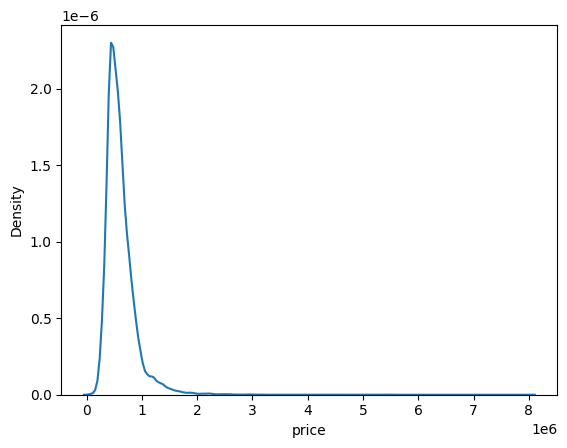

In [ ]:
sns.kdeplot(data.price)

In [ ]:
data['Price_Transformed']= np.log(data.price)

In [ ]:
data.Price_Transformed.skew()

np.float64(0.4731646269984763)

In [ ]:
list2 =find_anamolies(data.Price_Transformed)

In [ ]:
len(list2)

213

<Axes: xlabel='Price_Transformed', ylabel='Density'>

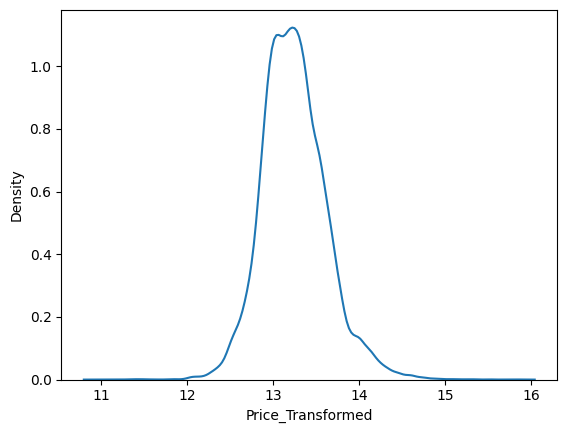

In [ ]:
sns.kdeplot(data.Price_Transformed)

In [ ]:
data['Prcie_Transformed_2']= np.log(data.Price_Transformed)

In [ ]:
data.Prcie_Transformed_2.skew()

np.float64(0.33092530655758573)

In [ ]:
list_3 = find_anamolies(data.Prcie_Transformed_2)

In [ ]:
len(list_3)

182

<Axes: xlabel='Prcie_Transformed_2', ylabel='Density'>

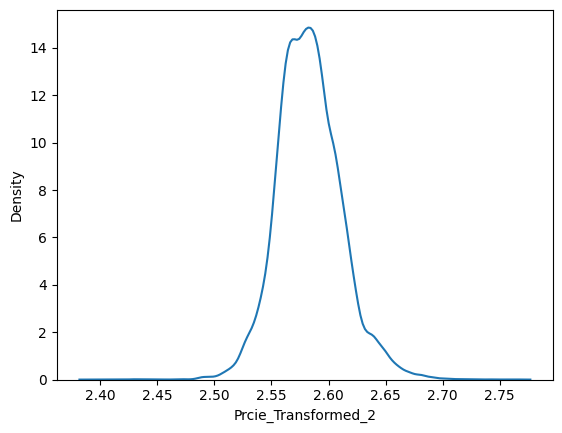

In [ ]:
sns.kdeplot(data.Prcie_Transformed_2)

**Compared with the previous transformed plot**

*   Price_Transformed: Nearly normal but still had a slight right skew.
*   Price_Transformed_2: More symmetric with a shorter right tail, making it the better transformation






*   Anything Below 40 and Above 80 are considered as Outliers



*   **BOXPLOT**







<Axes: >

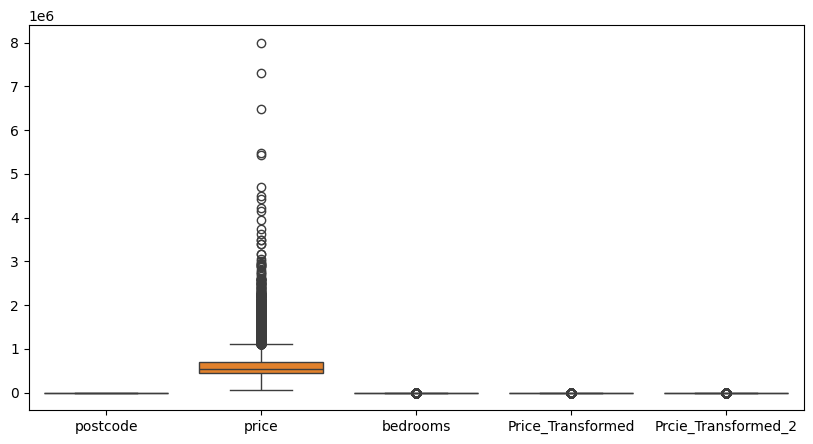

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data)

The above code displays the plot below.

As we can see, it considers everything above 75 or below ~ -35 to be an outlier. The results are very close to method 1 above.

In [ ]:
Q1 = data['price'].quantile(0.25)   #IQR Method
Q1 = data['price'].quantile(0.25)
Q3 = data['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = data[(data['price'] >= lower) & (data['price'] <= upper)]

In [ ]:
data.head()

,datesold,postcode,price,propertyType,bedrooms,Price_Transformed,Prcie_Transformed_2
0,2007-02-07 00:00:00,2607,525000,house,4,13.171154,2.578029
1,2007-02-27 00:00:00,2906,290000,house,3,12.577636,2.531920
2,2007-03-07 00:00:00,2905,328000,house,3,12.700769,2.541663
3,2007-03-09 00:00:00,2905,380000,house,4,12.847927,2.553182
4,2007-03-21 00:00:00,2906,310000,house,3,12.644328,2.537209


In [ ]:
df.head()

,datesold,postcode,price,propertyType,bedrooms,Price_Transformed,Prcie_Transformed_2
0,2007-02-07 00:00:00,2607,525000,house,4,13.171154,2.578029
1,2007-02-27 00:00:00,2906,290000,house,3,12.577636,2.531920
2,2007-03-07 00:00:00,2905,328000,house,3,12.700769,2.541663
3,2007-03-09 00:00:00,2905,380000,house,4,12.847927,2.553182
4,2007-03-21 00:00:00,2906,310000,house,3,12.644328,2.537209


<Axes: >

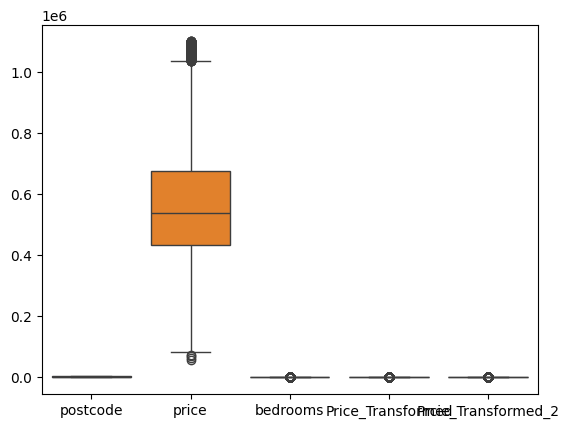

In [ ]:
sns.boxplot(df)

In [ ]:
#Z- score method

from scipy.stats import zscore
df_1 = data[(np.abs(zscore(data['price'])) < 3)]

In [ ]:
df_1.head()

,datesold,postcode,price,propertyType,bedrooms,Price_Transformed,Prcie_Transformed_2
0,2007-02-07 00:00:00,2607,525000,house,4,13.171154,2.578029
1,2007-02-27 00:00:00,2906,290000,house,3,12.577636,2.531920
2,2007-03-07 00:00:00,2905,328000,house,3,12.700769,2.541663
3,2007-03-09 00:00:00,2905,380000,house,4,12.847927,2.553182
4,2007-03-21 00:00:00,2906,310000,house,3,12.644328,2.537209


<Axes: >

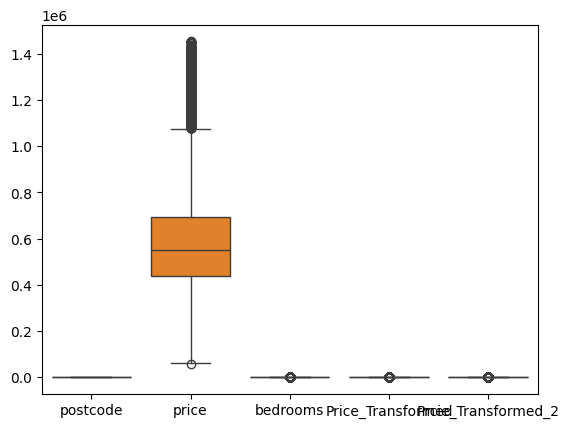

In [ ]:
sns.boxplot(df_1)



**Insight**

*   The majority of house prices are between approximately $430,000 and $690,000, with a median price of around $550,000. However, several properties are priced above approximately $1.08 million, making them high-value outliers and indicating a right-skewed price distribution

